## Task 1: Develop predictive regression models using Linear Regression techniques for continuous-valued data analysis
### (Suggested Dataset: Boston Housing Dataset or equivalent).

In [1]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
import warnings

warnings.filterwarnings("ignore")

boston = fetch_openml(name="boston",version = 1, as_frame = False)

X_boston = boston.data
y_boston = boston.target.astype(float)

scaler = StandardScaler()
X_boston_scaled = scaler.fit_transform(X_boston)

X_train, X_test, y_train, y_test = train_test_split(
        X_boston_scaled, y_boston, test_size = 0.20, random_state = 42)

print("Training set shape :", X_train.shape)
print("Test Set Shape : ", X_test.shape)


Training set shape : (404, 13)
Test Set Shape :  (102, 13)


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Linear Regression Model Trained Succuessfully")

Linear Regression Model Trained Succuessfully


In [3]:
mae = mean_absolute_error(y_test,lr_preds)
mse = mean_squared_error(y_test,lr_preds)
r2 = r2_score(y_test,lr_preds)

print(f"Mean Absolute Error : {mae :.2f}")
print(f"Mean Squared Error : {mse : 2f}")
print(f"R2 Score : {r2:.2f}")

Mean Absolute Error : 3.19
Mean Squared Error :  24.291119
R2 Score : 0.67


In [4]:
comparison_df = pd.DataFrame({
    "Actual Price" : y_test[:10],
    "Predicted Price" : lr_preds[:10]
})

print("Actual Data Vs Predicted House Prices")
print(comparison_df)

Actual Data Vs Predicted House Prices
   Actual Price  Predicted Price
0          23.6        28.996724
1          32.4        36.025565
2          13.6        14.816944
3          22.8        25.031979
4          16.1        18.769880
5          20.0        23.254429
6          17.8        17.662538
7          14.0        14.341190
8          19.6        23.013207
9          16.8        20.632456


In [5]:
results = pd.DataFrame({
    "Metric" : ["Mean Absolute Error",
                "Mean Squared Error",
                "R2 Score"
               ],
    "Value" : [mae,mse,r2]
})

print("---- Linear Regression Performance -----")
print(results.to_string(index=False))

---- Linear Regression Performance -----
             Metric     Value
Mean Absolute Error  3.189092
 Mean Squared Error 24.291119
           R2 Score  0.668759


## Task 2: Implement Support Vector Regression and Decision Tree Regression models for comparative performance analysis
### (Suggested Dataset: Boston Housing Dataset).

In [6]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# Load Boston Housing Dataset
boston = fetch_openml(name="boston", version=1, as_frame=False)

X = boston.data
y = boston.target.astype(float)

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=.20,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

Training set shape: (404, 13)
Testing set shape : (102, 13)


In [7]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score

# Train SVR Model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)

# Prediction
svr_preds = svr_model.predict(X_test)

# Evaluation
svr_r2 = r2_score(y_test, svr_preds)

print(f"Support Vector Regression R2 Score: {svr_r2:.2f}")

Support Vector Regression R2 Score: 0.65


In [8]:
from sklearn.tree import DecisionTreeRegressor

# Train Decision Tree Model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Prediction
dt_preds = dt_model.predict(X_test)

# Evaluation
dt_r2 = r2_score(y_test, dt_preds)

print(f"Decision Tree Regression R2 Score: {dt_r2:.2f}")

Decision Tree Regression R2 Score: 0.86


In [9]:
comparison_df = pd.DataFrame({
    'Regression Model': [
        'Support Vector Regression',
        'Decision Tree Regression'
    ],
    'R2 Score': [
        svr_r2,
        dt_r2
    ]
})

print("----- Performance Comparison -----")
print(comparison_df.to_string(index=False))

----- Performance Comparison -----
         Regression Model  R2 Score
Support Vector Regression  0.649643
 Decision Tree Regression  0.857963


### Task 3: Evaluate regression models using learning curves and appropriate error metrics.

In [10]:
import pandas as pd
import numpy as np
import warnings

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# Load Boston Housing Dataset
boston = fetch_openml(name="boston", version=1, as_frame=False)

X = boston.data
y = boston.target.astype(float)

# Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set Shape :", X_train.shape)
print("Testing Set Shape  :", X_test.shape)

Training Set Shape : (404, 13)
Testing Set Shape  : (102, 13)


In [11]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", round(mae,2))
print("Mean Squared Error :", round(mse,2))
print("Root Mean Squared Error :", round(rmse,2))
print("R2 Score :", round(r2,2))

Mean Absolute Error : 3.19
Mean Squared Error : 24.29
Root Mean Squared Error : 4.93
R2 Score : 0.67


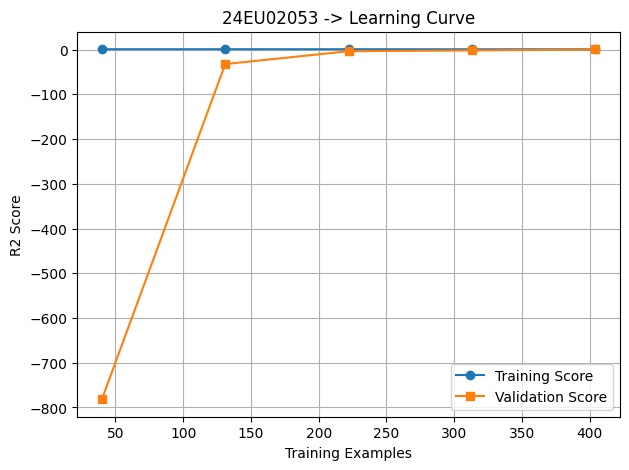

In [13]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(),
    X_scaled,
    y,
    cv=5,
    scoring='r2'
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label="Training Score")
plt.plot(train_sizes, test_mean, marker='s', label="Validation Score")
plt.xlabel("Training Examples")
plt.ylabel("R2 Score")
plt.title("24EU02053 -> Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
results = pd.DataFrame({
    "Metric":[
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ],
    "Value":[
        mae,
        mse,
        rmse,
        r2
    ]
})

print("Regression Model Performance")
print(results.to_string(index=False))

Regression Model Performance
  Metric     Value
     MAE  3.189092
     MSE 24.291119
    RMSE  4.928602
R2 Score  0.668759
